In [1]:
from datasets import load_dataset

import numpy as np
import torch
import matplotlib.pyplot as plt
from configurations.plot_config import set_font_sizes, apply_general_styles, create_fig, FONTSIZES
from configurations.data_config import make_params_dict , load_data, save_fig, save_data

from attention_nn.dataset import get_all_sentences, build_tokenizer, get_dataloader
from attention_nn.model import create_model

apply_general_styles()

/u/c/cerazova/miniconda3/envs/transf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data Statistics

In [45]:
# Define configuration

config = {
    'dataset_size': 10000,
    'train_fraction': 0.9,
    'batch_size': 1,
    'L': 128,
    'datasource': 'roneneldan/TinyStories',
}

# Prepare data loaders and tokenizer
print('Preparing data loaders...')
train_dataloader, val_dataloader , tokenizer = get_dataloader(config)
vocab_size = tokenizer.get_vocab_size()
print(f'Vocabulary size = {vocab_size}. Maximum entropy per token = {np.log(vocab_size):.4f} nats.')
pad_id = tokenizer.token_to_id("[PAD]")

Preparing data loaders...
Min sequence length = 53
Max sequence length = 1040
Vocabulary size = 8043. Maximum entropy per token = 8.9926 nats.


In [46]:
# Measure token frequency in all dataset for each position in sequence
data_stats = {}
token_counts = np.zeros((config['L'], vocab_size))

for batch in train_dataloader:
    input = batch['input'][0].numpy() # (seq_len,)
    token_counts[np.arange(config['L']), input] += 1
for batch in val_dataloader:
    input = batch['input'][0].numpy() # (seq_len,)
    token_counts[np.arange(config['L']), input] += 1

# Eliminate data from padding tokens
token_counts[:, pad_id] = 0
data_stats['unsorted_token_counts'] = token_counts.copy()

total_counts = token_counts.sum(axis=0)  # (vocab_size,)
sorted_tokens = np.argsort(-total_counts)  # Indices of tokens sorted by frequency descending
token_counts = token_counts[:, sorted_tokens]  # Sort token counts accordingly
total_counts = total_counts[sorted_tokens]

# Compute entropy per position
token_frequencies = token_counts / token_counts.sum(axis=1, keepdims=True)  # (L, vocab_size)
entropies = -np.nansum(token_frequencies * np.log(token_frequencies + 1e-12), axis=1)  # (L,)

# Compute total entropy
total_token_frequencies = total_counts / total_counts.sum()
total_entropy = -np.nansum(total_token_frequencies * np.log(total_token_frequencies + 1e-12))

data_stats['sorted_token_counts'] = token_counts.copy()
data_stats['sorted_tokens'] = sorted_tokens
data_stats['entropies_per_position'] = entropies
data_stats['total_entropy'] = total_entropy
data_stats['sorted_rank'] = np.argsort(sorted_tokens)

names = ['dataset_size','L']
params = {k: config[k] for k in names}
save_data(data_stats,'token_counts','data_statistics',params=params,base_dir='../data')

File saved with pickle.dump on /u/c/cerazova/Transformers/data/data_statistics as token_counts_L128_dataset_size10000.pkl


Figure saved on /u/c/cerazova/Transformers/plots/2026-01 as token_frequencies_L128_dataset_size10000.png


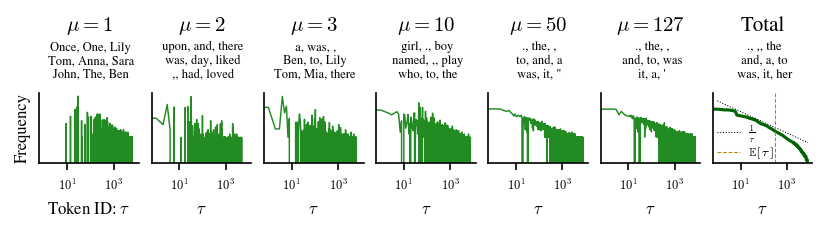

Figure saved on /u/c/cerazova/Transformers/plots/2026-01 as entropy_per_seq_position_L128_dataset_size10000.png


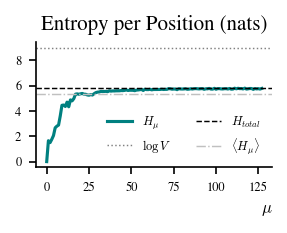

In [7]:
# Setup and variables for plotting
L = config['L']
window = 1
plt.rcParams['text.usetex'] = False
k = 9
# pos_to_plot = np.linspace(1,L-1-window,m).astype(int)
pos_to_plot = [1,2,3,10,50,L-1]
m = len(pos_to_plot)
tau_av = (total_token_frequencies*np.arange(vocab_size)).sum()
h_ratios = [0.5,1.0]
set_font_sizes(conf='tight')
fig , axes = create_fig(ncols=m+1,nrows=2,size='double',h=0.2,w=0.75,sharey=True, h_ratios=h_ratios)

for i in range(m+1):
    if i < m:
        # print(pos_to_plot[i],pos_to_plot[i]+window)
        # freqs = token_counts[pos_to_plot[i]:pos_to_plot[i]+window].sum(axis=0)
        freqs = token_counts[pos_to_plot[i]]
    else:
        freqs = total_counts
    freqs /= freqs.sum()
    # Top k tokens ids
    top_k_tokes_id = np.argsort(-freqs)[:k]
    top_k_tokens = [tokenizer.id_to_token(sorted_tokens[j]) for j in top_k_tokes_id]
    # print(f'idx={i}',top_k_tokens)
    ax = axes[0,i]
    ax.set_axis_off()
    
        
    # if i == 0: ax.set_ylabel('Frequent\nTokens',size=FONTSIZES['s'])
    text = '\n'.join([f' {top_k_tokens[j]}, {top_k_tokens[j+1]}, {top_k_tokens[j+2]}' for j in range(0,k-2,3)]) 
    ax.text(0.5, 0.5, text, fontsize=FONTSIZES['xs'], va='center', ha='center', transform=ax.transAxes)
    ax.set_title(rf'$\mu={pos_to_plot[i]}$' if i < m else 'Total')


    # Plot token frequency distribution
    ax = axes[1,i]
    if i == 0: ax.set_ylabel('Frequency',size=FONTSIZES['s'])
    
    ax.plot(freqs,color='forestgreen' if i < m else 'darkgreen',lw=0.7 if i < m else 1.5)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'Token ID: $\tau$' if i == 0 else r'$\tau$',size=FONTSIZES['s'])
    ax.set_xticks([10,1000],[r'$10^1$',r'$10^3$'])
    if i == m:
        plt.rcParams['text.usetex'] = True
        ax.plot(np.arange(1,vocab_size+1),0.25/np.arange(1,vocab_size+1),color='k',ls=':',lw=0.5,label=r'$\frac{1}{\tau}$')
        ax.axvline(tau_av, color='darkgoldenrod', ls='--', lw=0.5, label=r'$\mathbb{E}[\tau]$')
        ax.legend(fontsize=FONTSIZES['xs']*0.9,frameon=False,loc=(0.0,0.0),ncols=1)
        plt.rcParams['text.usetex'] = False
    ax.set_yticks([])
    
# fig.text(0.025, 0.75, 'Frequent\nTokens', fontsize=FONTSIZES['s'], va='center', ha='center', transform=fig.transFigure,rotation=90)

names = ['dataset_size','L']
params = {k: config[k] for k in names}
save_fig(fig,'token_frequencies',params=params,date=True)
plt.show()


fig , axes = create_fig(ncols=1,nrows=1,size='double',h=0.2,w=0.25)
ax = axes

ax.plot(entropies, color='teal', lw=1.5,label=r'$H_\mu$')
ax.set_xlabel(r'$\mu$',size=FONTSIZES['s'],loc='right')
# ax.set_ylabel(r'$H_\mu$',size=FONTSIZES['s'])
ax.axhline(np.log(vocab_size), color='gray', ls=':', lw=0.7, label=r'$\log V$')
ax.axhline(total_entropy, color='k', ls='--', lw=.7, label=r'$H_{total}$')
ax.axhline(entropies.mean(), color='silver', ls='-.', lw=.7, label=r'$\langle H_\mu \rangle$')
ax.legend(fontsize=FONTSIZES['xs'],frameon=False,ncols=2)
ax.set_title('Entropy per Position (nats)')
save_fig(fig,'entropy_per_seq_position',params=params,date=True)
plt.show()


# Model at Initialization

In [38]:
# Define configuration

config = {
    'd': 10000,
    'dataset_size': 10000,
    'train_fraction': 0.9,
    'batch_size': 64,
    'L': 500,
    'dropout': 0.0,
    'rank': None,
    'num_epochs': 5,
    'lr': 0.001,
    'datasource': 'roneneldan/TinyStories',
    'fr_emb': False,
    'fr_att': False,
    'type_enc': 'learned',
    'skip_residual': False,
    'sigma': 0.5,
    'beta': 1.0,
    'amp':1.0,
    'unmb': True
}



In [39]:
# Prepare data loaders and tokenizer
print('Preparing data loaders...')
train_dataloader, val_dataloader , tokenizer = get_dataloader(config)
config['vocab_size'] = tokenizer.get_vocab_size()
print(f'Vocabulary size = {config["vocab_size"]}. Maximum entropy per token = {np.log(config["vocab_size"]):.4f} nats.')
pad_id = tokenizer.token_to_id("[PAD]")

# Set device and build model
model , device = create_model(config)
print(f'Model built on device: {device}')

Preparing data loaders...
Min sequence length = 53
Max sequence length = 1040
Vocabulary size = 8043. Maximum entropy per token = 8.9926 nats.
Model built on device: cuda


In [40]:

CE_loss = torch.nn.CrossEntropyLoss(ignore_index=pad_id,label_smoothing=0.0)
for batch in train_dataloader:
    input = batch['input'].to(device) # (batch_size, seq_len)
    label = batch['label'].to(device) # (batch_size, seq_len)
    mask = batch['attention_mask'].to(device) # (batch_size, seq_len, seq_len)

    e = model.input_embeddings(input)  # (batch, seq_len, d_model)
    x = model.positional_encoding(e)  # (batch, seq_len, d_model)
    dot = model.attention_layer.dot(x) #/np.sqrt(config['d']) # (batch, seq_len, seq_len)
    A =  torch.softmax(dot.masked_fill(mask==0,-1e9), dim=-1)
    y = A @ x
    z = model.residual_connection(x, y)
    if model.U_matrix is not None:  # unmb=True
        U = model.U_matrix
    else:  # unmb=False
        U = model.input_embeddings.embedding.weight.t()
    logits = model.beta*torch.matmul(z, U)/np.sqrt(model.d) 
    prediction = torch.softmax(logits, dim=-1)

    loss = CE_loss(logits.view(-1,config['vocab_size']) , label.view(-1))
    
    # backward pass
    loss.backward()
    break

E = model.input_embeddings.embedding.weight.t()
W = model.attention_layer.W.weight
# projection_weight = model.projection.weight

print(f'Input dimension = {config["d"]}, vocabulary size = {config["vocab_size"]} , sequence length = {config["L"]}.')
print(f'{input.shape = }')
print(f'{e.shape = }')
print(f'{x.shape = }')
print(f'{dot.shape = }')
print(f'{A.shape = }')
print(f'{y.shape = }')
print(f'{z.shape = }')
print(f'{logits.shape = }')
print(f'{E.shape = }')
print(f'{W.shape = }')
# print(f'{projection_weight.shape = }')
print(f'{loss.item() = }')


Input dimension = 10000, vocabulary size = 8043 , sequence length = 500.
input.shape = torch.Size([64, 500])
e.shape = torch.Size([64, 500, 10000])
x.shape = torch.Size([64, 500, 10000])
dot.shape = torch.Size([64, 500, 500])
A.shape = torch.Size([64, 500, 500])
y.shape = torch.Size([64, 500, 10000])
z.shape = torch.Size([64, 500, 10000])
logits.shape = torch.Size([64, 500, 8043])
E.shape = torch.Size([10000, 8043])
W.shape = torch.Size([10000, 10000])
loss.item() = 9.056235313415527


grad_W.shape = (8043, 10000)
std = 0.000002
nrm = 0.000001


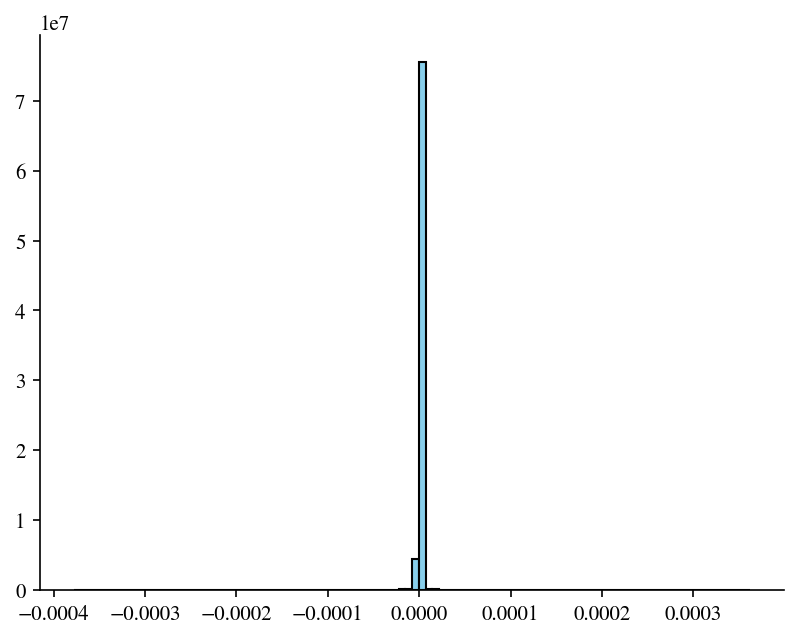

In [42]:
# get the gradient with respect to W

# grad_W = model.attention_layer.W.weight.grad.cpu().numpy()
grad_W = model.input_embeddings.embedding.weight.grad.cpu().numpy()
print(f'{grad_W.shape = }')

plt.hist(grad_W.flatten(), bins=100, color='skyblue', edgecolor='k')
plt.plot()
print(f'std = {grad_W.std():.6f}')
print(f"nrm = {np.sqrt(1/(config['batch_size']*config['L'])) * (1/config['d']):.6f}")

1.4120477


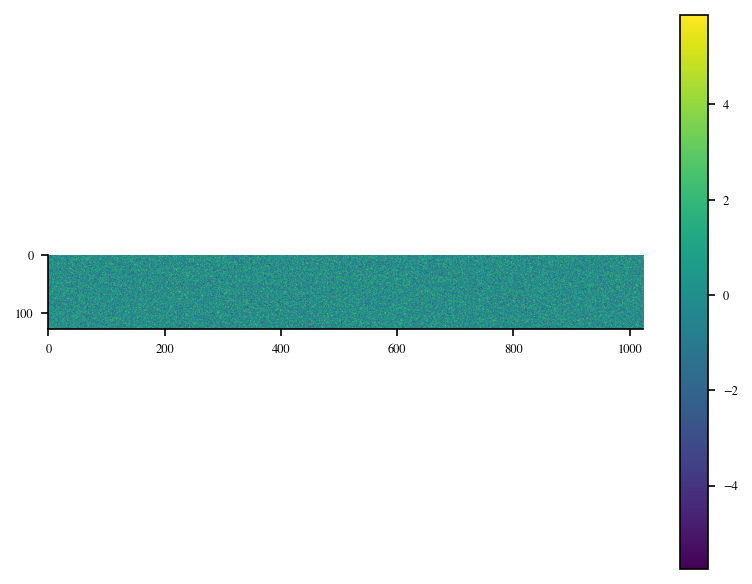

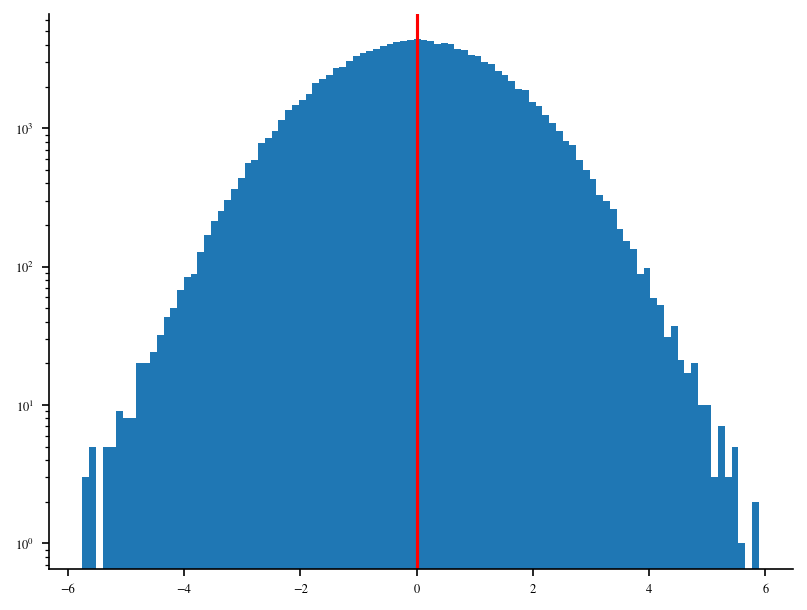

(0.0, 2420.193340951383)

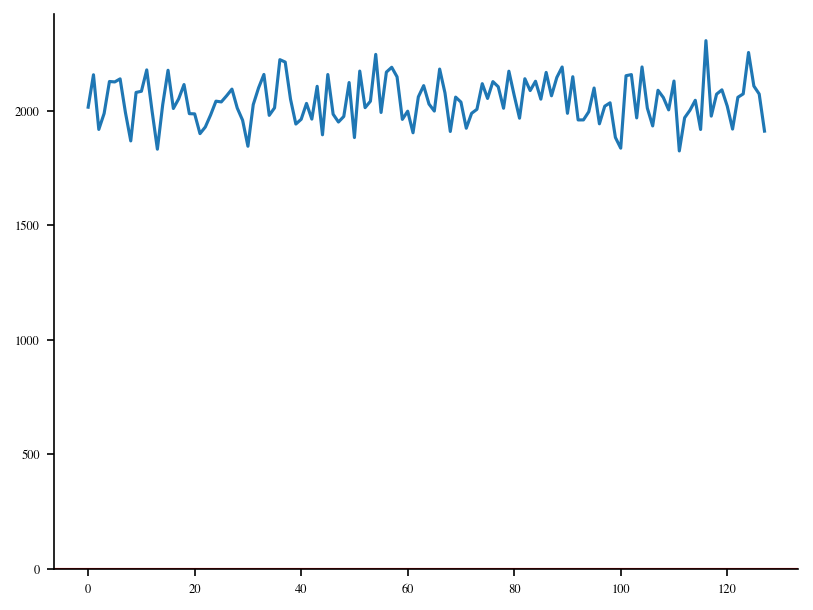

In [260]:
i_batch = 1

var_to_plot = (x)[i_batch].detach().cpu().numpy()  # (seq_len, d_model)

print(var_to_plot.std()   )
plt.imshow(var_to_plot)
plt.colorbar()

plt.show()
plt.hist(var_to_plot.flatten(), bins=100)
plt.yscale('log')
plt.axvline(x=1/config['vocab_size'], color='red')

plt.show()

plt.plot((var_to_plot**2).sum(axis=1))
plt.axhline(y=1/config['vocab_size'], color='red')
plt.ylim(bottom=0)

In [80]:
np.sqrt(1024)

np.float64(32.0)

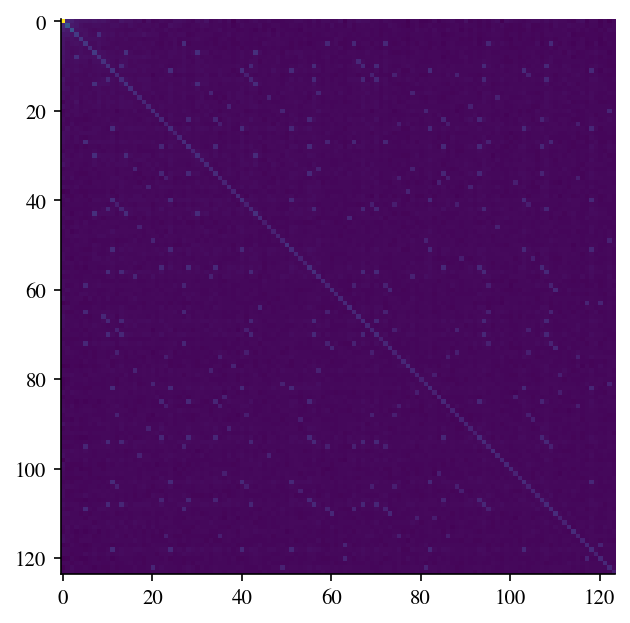

In [63]:
C = var_to_plot @ var_to_plot.T / var_to_plot.shape[1]
eigenvalues, eigenvectors = np.linalg.eigh(C)
# plt.scatter(eigenvalues,eigenvalues)
# plt.plot(np.sort(eigenvalues)[::-1])
plt.imshow(C)

In [64]:
i_batch = 10
beta = 1.0
prob = (beta*h[i_batch]).softmax(dim=-1).detach().cpu().numpy()  # (seq_len, vocab_size)
sequence = input[i_batch].detach().cpu().numpy()  # (seq_len,)

mu = 0
p = prob[mu]
tok = np.argmax(p)
print(f"Token with highest probability for position {mu+1}: {tok}  = '{tokenizer.id_to_token(tok)}' with probability {p[tok]:.6f}")
print(f"Token at position {mu}: {sequence[mu]} = '{tokenizer.id_to_token(sequence[mu])}'")
print(f"Actual token at position {mu+1}: {sequence[mu+1]}  = '{tokenizer.id_to_token(sequence[mu+1])}'")
print(f"probability of actual next token: {p[sequence[mu+1]]:.6f}")
print(f"Uniform probability: {1/config['vocab_size']:.6f}")
print(f'Participation ratio at position : {np.sum(p**2):.6f}')
plt.plot(prob[mu])
plt.axhline(1/config['vocab_size'], color='red', linestyle='--', label='Uniform probability')
plt.ylim(bottom=0)
# print(prob[mu])

NameError: name 'h' is not defined

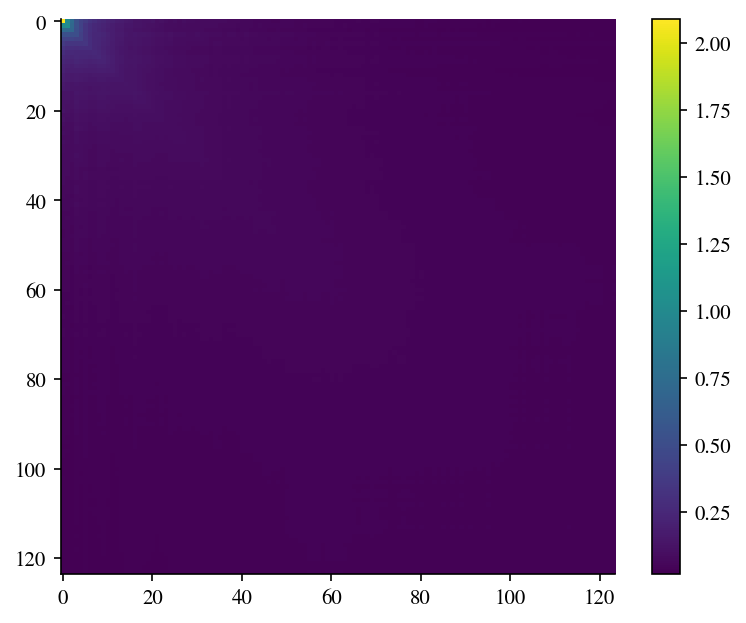

In [66]:
p = (y)[0].detach().cpu().numpy()
c = p @ p.T / config['d']
# c.shape
plt.imshow(c)
plt.colorbar()
# plt.imshow(p[i_batch].detach().cpu().numpy())

tensor(0.0001)
0.0001


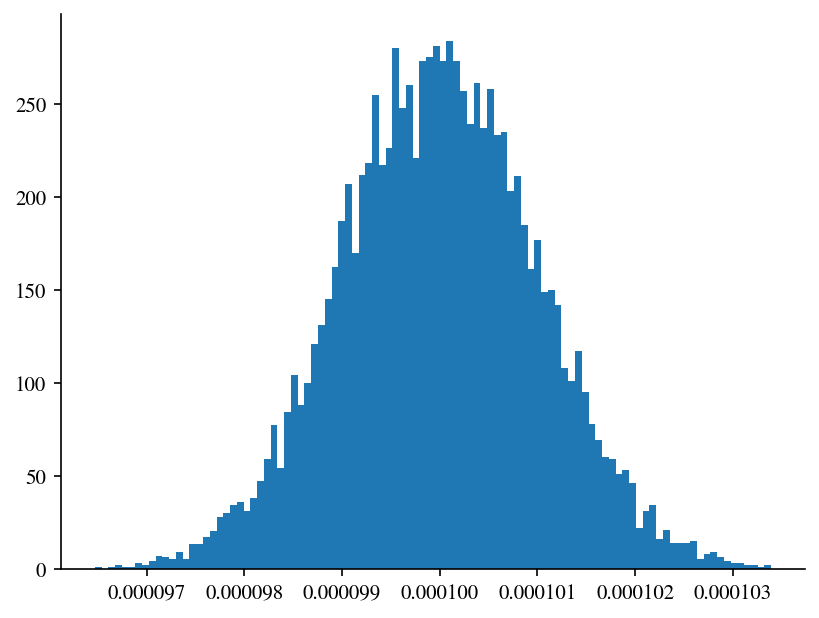

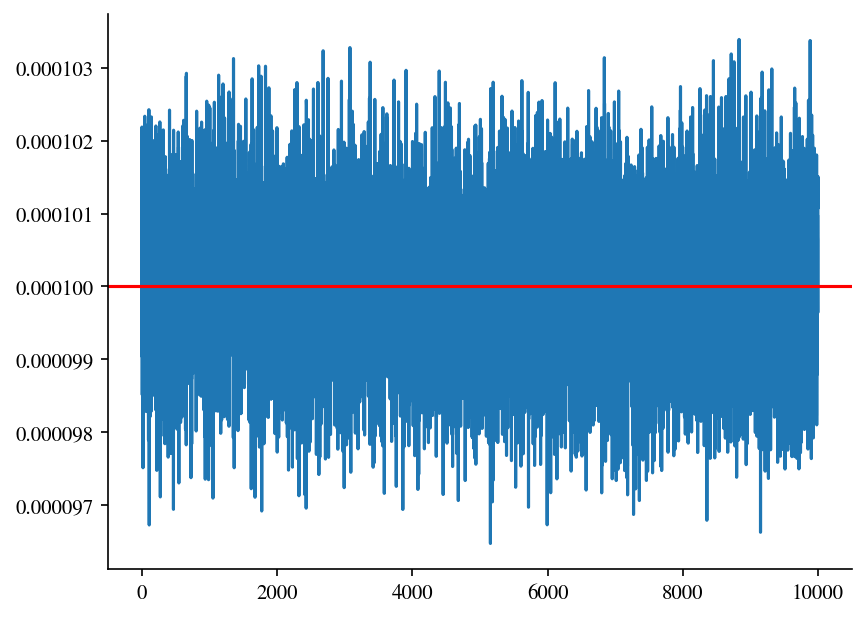

In [100]:
n = 10000
x = torch.randn(n)/np.sqrt(n)
e = torch.exp(x)
s = e.sum()
a = e / s

plt.hist(a.numpy(), bins=100)
print((a**2).sum())
print(1/n)
# plt.hist(a.numpy(), bins=100)
plt.show()
plt.plot(a.numpy())
plt.axhline(1/n, color='red')

# Initial clean training

In [132]:
# Fixed Model Parameters
d = 512
dataset_size = 10000
L = 128
rank = None
batch_size = 64
num_epochs = 10

# Architectural Parameters
skip_residual = False
fr_emb = False
fr_att = False

# Hyperparameters
beta = 1.0
lr = 0.05



# Loop over various configurations  =  amp, type_enc,  unmb
sigma = 0.5
amp = 1.0
type_enc = 'learned'
unmb = True


fix_names = ['rank','d','L','dataset_size','skip_residual','fr_att','fr_emb','batch_size','lr','beta']
var_names = ['type_enc','amp','unmb','sigma']
params = make_params_dict(fix_names , var_names)


summary_scalar = load_data('summary_log',experiment_name='new_evolution_scalar', params=params)
summary_matrices = load_data('summary_log',experiment_name='new_evolution_matrices', params=params)


print('In scalar summary:')
for key in summary_scalar.keys():
    if key != 'embedd_top_tokens':
        print(f'{key}: {summary_scalar[key].shape}')

bs = batch_size
n = dataset_size

File summary_log_amp1_sigma0.5_type_enclearned_unmbTrue.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_evolution_scalar/L128_batch_size64_beta1_d512_dataset_size10000_fr_attFalse_fr_embFalse_lr0.05_rankNone_skip_residualFalse
File summary_log_amp1_sigma0.5_type_enclearned_unmbTrue.pkl loaded with pickle.load from /u/c/cerazova/Transformers/data/new_evolution_matrices/L128_batch_size64_beta1_d512_dataset_size10000_fr_attFalse_fr_embFalse_lr0.05_rankNone_skip_residualFalse
In scalar summary:
evaluation_steps: (268,)
train_loss: (268,)
val_loss: (268,)
entropy: (268, 5)
part_ratio: (268, 5)
pos_attended: (268, 5)
pred_entropy: (268, 128)
att_in_fractions: (268, 5, 128)
KL_uniform: (268,)
KL_tot: (268,)
KL_mu: (268,)
average_rank: (268, 5)
embedd_eigvals: (268, 512)
embedd_mean: (268,)
embedd_std: (268,)
W_eigvals: (268, 512)
W_mean: (268,)
W_std: (268,)
sequence_fractions: (5,)
vocab_size: ()
grad_U_matrix: (268,)
grad_embedding: (268,)
grad_positional_encoding: (268

Figure saved on /u/c/cerazova/Transformers/plots/2026-01 as training_curve_nolb_L128_amp1_bs64_d512_lr0.05_n10000_sigma0.5_type_enclearned_unmbTrue.png


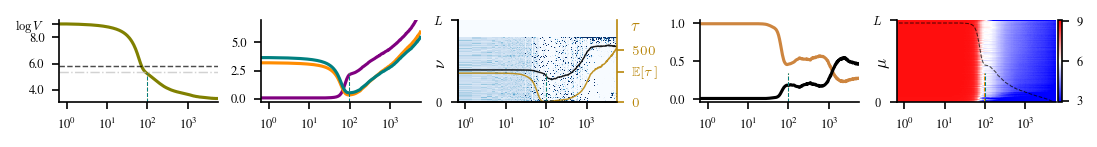

In [133]:
# Setup and variables
step_scalar = summary_scalar['evaluation_steps']
vocab_size = int(summary_scalar['vocab_size'])
sequence_fractions = summary_scalar['sequence_fractions']
i_seq_frac = 3
f = sequence_fractions[i_seq_frac]
idx_tot = np.argmin(summary_scalar['KL_tot'])
idx_mu = np.argmin(summary_scalar['KL_mu'])
lbls = False

plt.rcParams['text.usetex'] = False

set_font_sizes(conf='tight')

# Create figure
fig , axes = create_fig(nrows=1,ncols=5,size='double',h=0.14 if lbls else 0.12) # h=0.15

# Loss
ax = axes[0]
ax.plot(step_scalar,summary_scalar['val_loss'], color='olive',ls='-')
# ax.plot(step_scalar,summary_scalar['train_loss'], color='k',ls='--',lw=1)
ax.axhline(total_entropy, color='k', ls='--', lw=.7, label=r'$H_{total}$',alpha=0.7)
ax.axhline(entropies.mean(), color='silver', ls='-.', lw=.7, label=r'$\langle H_\mu \rangle$',alpha=0.7)
yticks = [4,6,8]
ylabels = [f'{y:.1f}' for y in yticks]
ax.set_yticks([*yticks,np.log(vocab_size)], [*ylabels, r'$\log V$'])
if lbls:
    ax.set_title('Val Loss',size=FONTSIZES['s'])
    ax.legend(frameon=False,ncols=1,loc=(0.45,0.5))


# KL divergences
ax = axes[1]
ax.plot(step_scalar,summary_scalar['KL_uniform'], label=r'$P_{uni}$', color='purple',ls='-')
ax.plot(step_scalar,summary_scalar['KL_tot'], label=r'$P_{tot}$', color='darkorange',ls='-')
ax.plot(step_scalar,summary_scalar['KL_mu'], label=r'$P_{\mu}$', color='teal',ls='-')
ax.set_ylim(top=7)
if lbls:
    ax.set_title(r'$D_{KL}(P_{emp}|\text{Prob}_\theta)$',size=FONTSIZES['s'])
    ax.legend(frameon=False,ncols=2,loc=(0.04,0.49))


# Sparcity Measures
ax = axes[3]
ax.plot(step_scalar, summary_scalar['entropy'][:,i_seq_frac], label=r'$H$', color='peru',ls='-')
ax.plot(step_scalar, summary_scalar['part_ratio'][:,i_seq_frac], label='PR', color='k',ls='-')
if lbls:
    ax.set_title(fr'Sparcity at ${{\mu = {f}L}}$',size=FONTSIZES['s'])
    ax.legend(frameon=False,ncols=1)

# Prediction Entropy
ax = axes[4]
vmin , vmax = 2.9 , 9.1
cmesh = ax.pcolormesh(step_scalar, np.arange(config['L']), summary_scalar['pred_entropy'].T, cmap='bwr',vmax=vmax,vmin=vmin)
av_entropy = summary_scalar['pred_entropy'].mean(axis=1)
av_entropy = (av_entropy - vmin) * (config['L']-1) / (vmax - vmin)
ax.plot(step_scalar, av_entropy, color='k',ls='--',lw=0.5,alpha=0.7)
ax.set_ylim(0,L)
ax.set_yticks([0,L],['$0$','$L$'])
clb = plt.colorbar(cmesh,ax=ax,fraction=0.16, pad=0.01)
clb.set_ticks([3,6,9])
if lbls:
    ax.set_title(r'$H[\text{Prob}_\theta^{(\mu)}]$',size=FONTSIZES['s'])


# Attention Pattern
ax = axes[2]
attention_patterns = summary_scalar['att_in_fractions']  # (num_step_scalars, len(seq_fract), L)
mesh = ax.pcolormesh(step_scalar, np.arange(L), attention_patterns[:, i_seq_frac].T,cmap='Blues',vmax=0.04)
ax.plot(step_scalar,L*f*summary_scalar['pos_attended'][:,i_seq_frac], 
        label=r'$\langle \;\nu \rangle$', color='k',ls='-',lw=0.7,alpha=0.9)
ax.set_ylim(0,L)
ax.set_yticks([0,L],['$0$','$L$'])
plt.rcParams['text.usetex'] = True
ax2 = ax.twinx()
col = 'darkgoldenrod'
ax2.plot(step_scalar, summary_scalar['average_rank'][:, i_seq_frac], alpha=0.9,ls='-',
         label=r'$\mathrm{Avg. \; Rank}$', color=col, lw=0.7)
ax2.tick_params(axis='y', colors=col)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(col)
ax2.set_ylim(0, 790)
tau_av = (total_token_frequencies*np.arange(vocab_size)).sum()
ax2.set_yticks([0,tau_av,500],['0',r'$\mathbb{E}[\tau]$','500'])
plt.rcParams['text.usetex'] = False

if lbls:
    ax.set_title(rf'$\mathcal{{A}}_{{\mu \nu}} \text{{ at }} {{\mu = {f}L}}$')

ax.set_xscale('log')
lbs = ['(a)','(b)','(c)','(d)','(e)']
locs = np.linspace(0.02,1,6)[:-1]
for i in [0,1,2,3,4]:
    ax = axes[i]
    # Do the lines until half heigth of the current y-axis
    ylims = ax.get_ylim()
    ax.set_ylim(ylims)
    # Eliminate just minor ticks keeping major ticks and
    ax.tick_params(axis='both', which='minor', bottom=False, top=False, left=False, right=False,size=FONTSIZES['xxs'])
    ax.plot([step_scalar[idx_tot], step_scalar[idx_tot]], [ylims[0],ylims[0]+(ylims[1]-ylims[0])*0.35], color='darkorange', ls='--', lw=0.5)
    ax.plot([step_scalar[idx_mu], step_scalar[idx_mu]], [ylims[0],ylims[0]+(ylims[1]-ylims[0])*0.35], color='teal', ls='--', lw=0.5)
    # fig.text(locs[i],1.02,lbs[i], fontsize=FONTSIZES['s'], va='center', ha='center', color='k',transform=fig.transFigure)





# fig.text(0.98,0.03,'Step', fontsize=FONTSIZES['s'], va='center', ha='center', transform=fig.transFigure)
fig.text(0.58,0.86,r'$\tau$', fontsize=FONTSIZES['s'], va='center', ha='center', color=col,transform=fig.transFigure)
fig.text(0.4,0.58,r'$\nu$', rotation=90,fontsize=FONTSIZES['s'], va='center', ha='center', color='k',transform=fig.transFigure)
fig.text(0.81,0.58,r'$\mu$', rotation=90,fontsize=FONTSIZES['s'], va='center', ha='center', color='k',transform=fig.transFigure)


names = ['d','n','L','bs','lr','type_enc','sigma','amp','unmb']
params = make_params_dict(names)
save_fig(fig,'training_curve_nolb',params=params,date=True)

In [66]:
print('\nIn matrices summary:')
for key in summary_matrices.keys():
    if key != 'tokens' and key != 'tokens_attended' and key != 'special_batch':
        print(f'{key}: {summary_matrices[key].shape}')

i_batch = 1
i_seq_frac = 1
f = sequence_fractions[i_seq_frac]

# Input sequence
special_batch = summary_matrices['special_batch']
input = special_batch['input'][i_batch].detach().cpu().numpy()
tokens = summary_matrices['tokens']
sentence = [tokens[tau] for tau in input[:int((L)*f)+1]]

# add \n each w words
w = 25
lines = []
for i in range(0, len(sentence[1:-1]), w):
    lines.append(' '.join(sentence[1:-1][i:i+w]))
context = '\n'.join(lines)
next_token = sentence[-1]
title = r'$\boldsymbol{\tau}^*:$ '+ context + r'$\rightarrow$' + next_token
print(f'\n',context)
print(next_token)


In matrices summary:
matrix_steps: (8,)
A: (8, 3, 128, 128)
x: (8, 3, 128, 512)
e: (8, 3, 128, 512)
embeddings: (8, 8043, 512)
embedd_grad_norms: (8, 8043)
W: (8, 512, 512)

 Once upon a time , there was a little squirrel named Nutty . Nutty loved to play and run around in the forest . One
day , Nutty found a big nut but it was broken . Nutty was sad because he couldn ' t eat it . Nutty decided
to


In [67]:
def compute_vminmax(variable,nstd=0.1):
    '''
    Compute vmin and vmax for colormap centered at variable.mean()
    with nstd standard deviations.
    '''
    mean = variable.mean()
    std = variable.std()
    vmin = mean - nstd * std
    vmax = mean + nstd * std

    # vmin , vmax = variable.min() , variable.max()
    return vmin, vmax


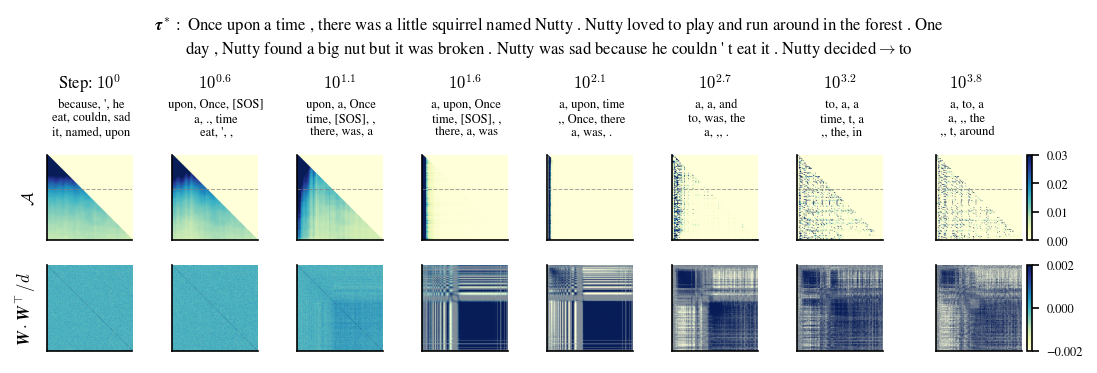

In [70]:
# Variables

step_matrix = summary_matrices['matrix_steps']
sequence_fractions = summary_scalar['sequence_fractions']
n = len(step_matrix)
h_ratios = [0.4,1,1]
top_attended_tokens = 9
top_grad_tokens = 6
norm = 10


# Create figure
set_font_sizes(conf='tight')
fig , axes = create_fig(nrows=3,ncols=n,size='double',h=0.33,sharex=False,sharey=False,h_ratios=h_ratios)
fig.suptitle(title, fontsize=FONTSIZES['s'])

for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

# Token being attended to
axs = axes[0]
for i , ax in enumerate(axs):
    ax.set_axis_off()
    log_time = rf'$10^{{{np.log10(step_matrix[i]+1):.2}}}$' 
    ax.set_title(r'Step: $10^0$' if i==0 else f'{log_time}',size=FONTSIZES['s'])
    variable = summary_matrices['tokens_attended'][i][i_batch][i_seq_frac]  
    text = '\n'.join([f' {variable[j]}, {variable[j+1]}, {variable[j+2]}' for j in range(0,top_attended_tokens-2,3)]) 
    ax.text(0.5, 0.5, text, fontsize=FONTSIZES['xs'], va='center', ha='center', transform=ax.transAxes)
    
# Attention Patterns
axs = axes[1]
axs[0].set_ylabel(r'$\boldsymbol{\mathcal{A}}$',size=FONTSIZES['s'])
for i , ax in enumerate(axs):
    variable = summary_matrices['A'][i,i_batch] # (L, L)
    vmin, vmax = compute_vminmax(variable,nstd=0.5)
    vmax = 0.03
    ax.imshow(variable,cmap='YlGnBu',vmin=0,vmax=vmax)
    ax.axhline(y=(L-1)*f, color='gray', ls='--', lw=0.5,alpha=0.7)
    # if i == 0:
    #     ax.set_yticks([0,L],[r'$0$',rf'$L$'])
    #     ax.set_xticks([0,L],[r'$0$',rf'$L$'])

    if i == n-1:
        plt.colorbar(ax.images[0], ax=ax)#, fraction=0.046, pad=0.04)

# Weigth Matrix W @ W.T
axs = axes[2]
axs[0].set_ylabel(r'$\boldsymbol{W} \cdot\boldsymbol{W}^\top/d$',size=FONTSIZES['s'])
for i , ax in enumerate(axs):
    W = summary_matrices['W'][i] 
    variable = W @ W.T / d  # (d, d)
    # vmin, vmax = compute_vminmax(variable)
    vmax = 0.002
    vmin = -0.002
    ax.imshow(variable,cmap='YlGnBu',vmin=vmin,vmax=vmax)
    # if i == 0:
    #     ax.set_yticks([0,d],[r'$0$',rf'$d$'])
    #     ax.set_xticks([0,d],[r'$0$',rf'$d$'])
    if i == n-1:
        
        fig.colorbar(ax.images[0], ax=ax)#, fraction=0.046, pad=0.04)

# ax = fig.add_subplot()
# sc = ax.scatter(x, y, c = z);
# fig.colorbar(sc, ax=ax);
# # Embeddings e@e.t
# axs = axes[3]
# axs[0].set_ylabel(r'$\boldsymbol{e}^\top \cdot\boldsymbol{e}/L$',size=FONTSIZES['xs'])
# for i , ax in enumerate(axs):
#     e = summary_matrices['e'][i,i_batch]  # (L, d)
#     variable = e.T @ e / L  # (d, d)
#     vmin, vmax = compute_vminmax(variable)
#     ax.imshow(variable,cmap='YlGnBu',vmin=0,vmax=vmax)
#     if True:
#         plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)

# # Positional encodings and embedings
# axs = axes[4]
# axs[0].set_ylabel(r'$\boldsymbol{p}^\top \cdot\boldsymbol{e}/L$',size=FONTSIZES['xs'])
# for i , ax in enumerate(axs):   
#     x = summary_matrices['x'][i,i_batch]  # (L, d)
#     e = summary_matrices['e'][i,i_batch]  # (L, d)
#     p = x - e  # (L, d)
#     variable = e.T @ p / L  # (d, d)
#     vmin, vmax = compute_vminmax(variable)
#     ax.imshow(variable,cmap='YlGnBu',vmin=0,vmax=vmax)
#     if True:
#         plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)

names = ['d','n','L','bs','lr','type_enc','sigma','amp','unmb']
params = make_params_dict(names)
# save_fig(fig,'matrices_evol',params=params,date=True)

In [ ]:
plt.im

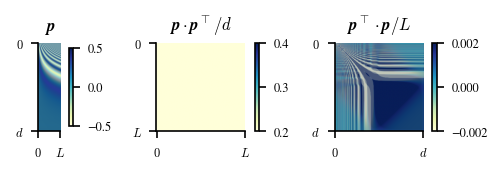

In [52]:
# Plot of positional encodings
x = summary_matrices['x'][0,i_batch]  # (L, d)
e = summary_matrices['e'][0,i_batch]  # (L, d)
p = x - e  # (L, d)

w_ratios = [0.7,1,1]
cmap='YlGnBu'
set_font_sizes(conf='tight')
fig , axes = create_fig(ncols=3,w_ratios=w_ratios,sharex=False,h=0.3)

ax = axes[0]
ax.imshow(p.T,cmap=cmap)
plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
ax.set_title(r'$\boldsymbol{p}$',size=FONTSIZES['s'])
ax.set_yticks([0,d],[r'$0$',rf'$d$'])
ax.set_xticks([0,L],[r'$0$',rf'$L$'])
ax = axes[1]
ax.imshow(p@p.T/d,cmap=cmap,vmin=0.2,vmax=0.4)
plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
ax.set_title(r'$\boldsymbol{p}\cdot \boldsymbol{p}^\top/d$',size=FONTSIZES['s'])
ax.set_xticks([0,L],[r'$0$',rf'$L$'])
ax.set_yticks([0,L],[r'$0$',rf'$L$'])
ax = axes[2]
ax.imshow(p.T @ p / L ,vmin=-0.002,vmax=0.002,cmap=cmap)
plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)
ax.set_title(r'$\boldsymbol{p}^\top \cdot \boldsymbol{p}/L$',size=FONTSIZES['s'])
ax.set_yticks([0,d],[r'$0$',rf'$d$'])
ax.set_xticks([0,d],[r'$0$',rf'$d$'])

params = {'d':d,'L':L,'type_enc':type_enc}
# save_fig(fig,'pos_encod',params=params,date=True)

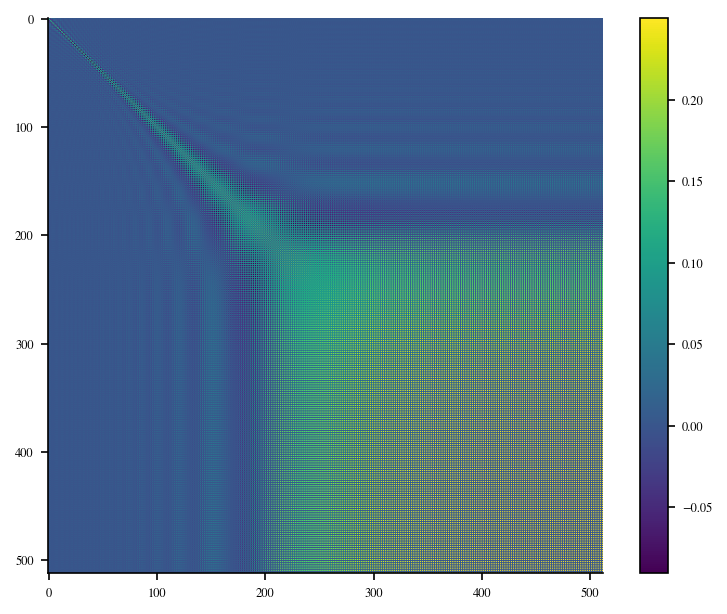

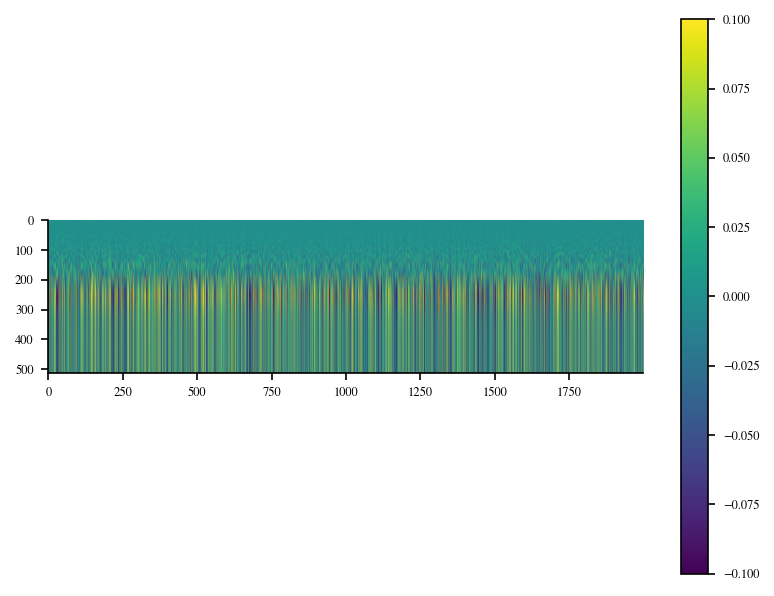

In [61]:
C = p.T @ p / L
V = 2000
U = np.random.randn(d,V)

R = C @ U / np.sqrt(d)
plt.imshow(C)
plt.colorbar()
plt.show()
plt.imshow(R,vmin=-0.1,vmax=0.1)
plt.colorbar()
plt.show()

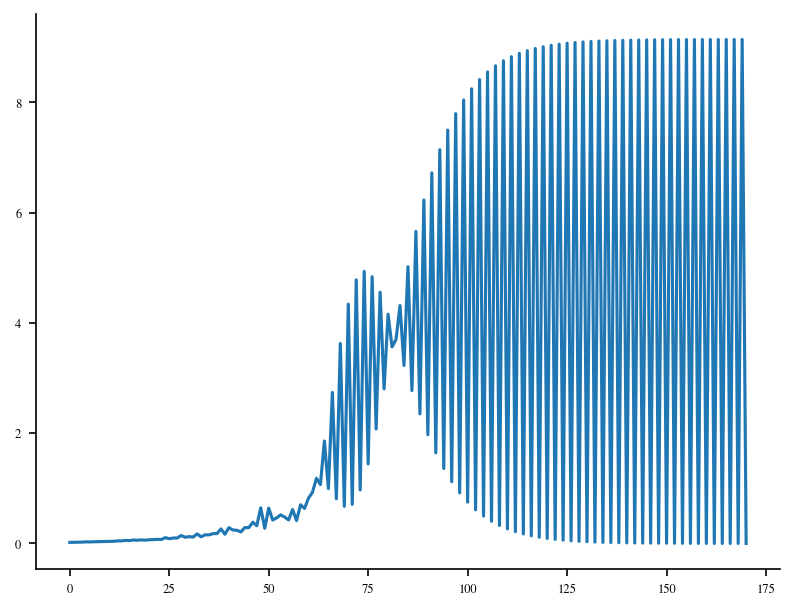

In [63]:
diag = np.diag(C@C.T)
plt.plot(diag[::2 +1])

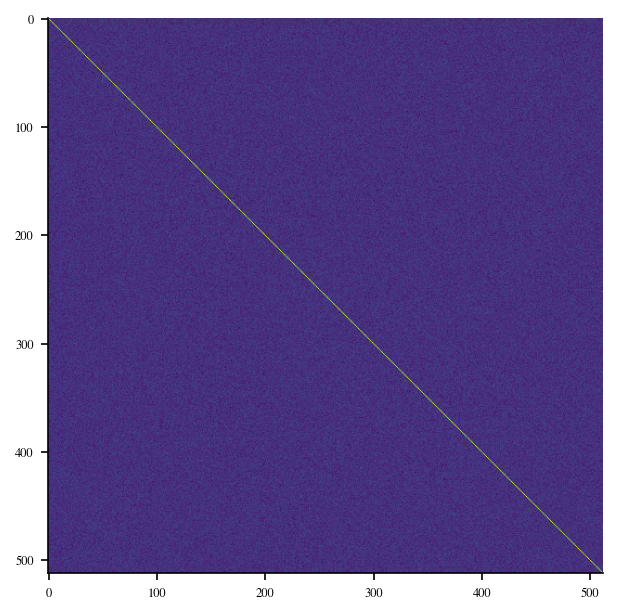

In [162]:
W = summary_matrices['W'][2] 
variable = W @ W.T / d  # (d, d)

plt.imshow(variable)

In [162]:
i_batch = 2
i_seq_frac = 0
idx = int((L-1)*sequence_fractions[i_seq_frac]) 
seq = summary_matrices['special_batch']['input'][i_batch][:idx+1]  # (seq_len,)
print('Special batch sequence:')
sequence = ' '.join([tokenizer.id_to_token(tok.item()) for tok in seq])
print(sequence)

Special batch sequence:
[SOS] Once upon a time , there was a small village . It was not big and fancy , but it was a very modest place


-0.10220718 0.16200387 0
-29.26584 10.477226 1
-14.946396 11.842981 2
-5.409953 11.582849 3
-3.1176066 12.156616 4
-2.2470846 12.410431 5


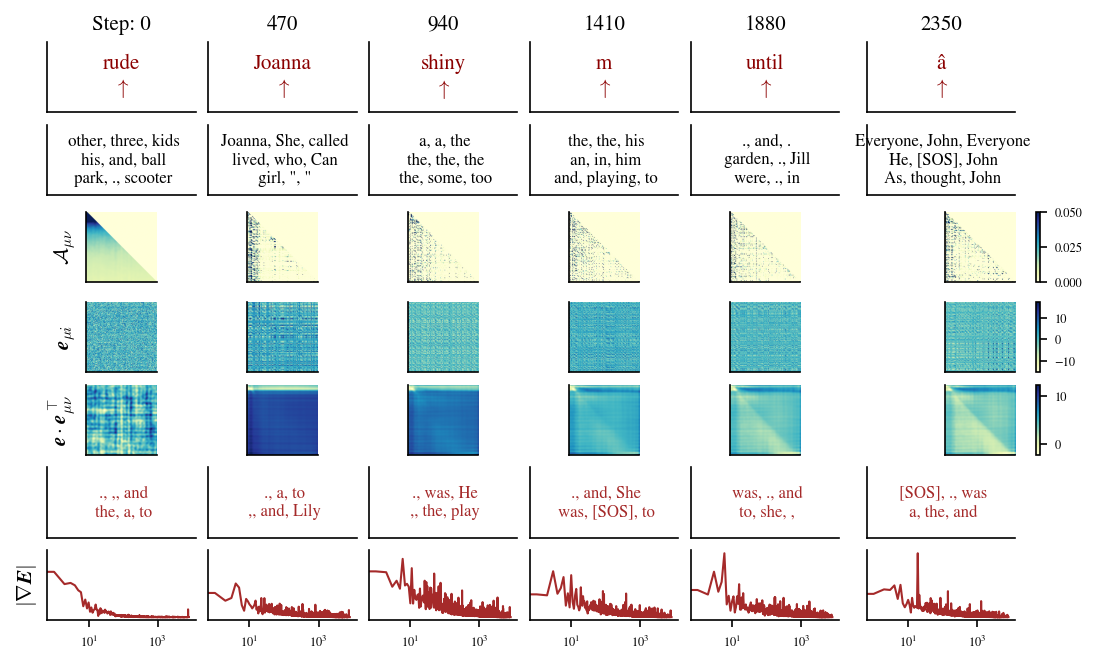

In [105]:
# Variables

step_matrix = summary_matrices['matrix_steps']
n = len(step_matrix)
h_ratios = [1,1,1,1,1,1,1]
top_attended_tokens = 9
top_grad_tokens = 6
# Create figure
fig , axes = create_fig(nrows=7,ncols=n,size='double',h=0.6,sharex=False,sharey=False,h_ratios=h_ratios)


for ax in axes.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
#     ax.set_axis_off()

# Next token to predict
axs = axes[0]
for i , ax in enumerate(axs):
    # ax.set_axis_off()
    ax.set_title(f'Step: {step_matrix[i]}' if i==0 else f'{step_matrix[i]}')
    variable = summary_matrices['tokens_next'][i][i_seq_frac]  
    ax.text(0.5, 0.5, f'{variable}\n'+r'$\uparrow$', fontsize=FONTSIZES['m'], va='center', ha='center', transform=ax.transAxes,color='darkred')

# Token being attended to
axs = axes[1]
for i , ax in enumerate(axs):
    # ax.set_axis_off()
    variable = summary_matrices['tokens_attended'][i][i_seq_frac]  
    text = '\n'.join([f' {variable[j]}, {variable[j+1]}, {variable[j+2]}' for j in range(0,top_attended_tokens-2,3)]) 
    ax.text(0.5, 0.5, text, fontsize=FONTSIZES['s'], va='center', ha='center', transform=ax.transAxes)
    

# Attention Patterns
axs = axes[2]
axs[0].set_ylabel(r'$\mathcal{A}_{\mu \nu}$')
for i , ax in enumerate(axs):
    variable = summary_matrices['A'][i]  # (L, L)
    ax.imshow(variable,vmax=0.05,cmap='YlGnBu')
    
    if i == n-1:
        plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)


axs = axes[3]
axs[0].set_ylabel(r'$\boldsymbol{e}_{\mu i}$')
for i , ax in enumerate(axs):
    e = summary_matrices['e'][i]  # (L, d)
    W = summary_matrices['W'][i]  # (d, d)
    variable = e @ W @ e.T / d  # (L, L)
    ax.imshow(variable,cmap='YlGnBu')
    if i == n-1:
        plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)

# p W p^T
axs = axes[4]
axs[0].set_ylabel(r'$\boldsymbol{e} \cdot \boldsymbol{e}^\top_{\mu \nu}$')
for i , ax in enumerate(axs):
    p = summary_matrices['x'][i]  - summary_matrices['e'][i]  # (L, d)
    W = summary_matrices['W'][i]  # (d, d)
    variable = p @ W @ p.T / d  # (L, L)
    # variable =  auxiliar @ auxiliar.T/d  # (L, L)
    print(variable.min(), variable.max(),i)
    ax.imshow(variable,cmap='YlGnBu')#,vmin=-0.05,vmax=0.05)
    if i == n-1:
        plt.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.04)

# Top embedding gradient tokens
axs = axes[5]
# axs[0].set_ylabel(r'Top Gradients')
for i , ax in enumerate(axs):
    variable = summary_matrices['embedd_grad_norms'][i]  # (vocab_size,)
    top_gradient_tokens = np.argsort(-variable)[:top_grad_tokens]
    tokens = [tokenizer.id_to_token(j) for j in top_gradient_tokens]
    text = '\n'.join([f' {tokens[j]}, {tokens[j+1]}, {tokens[j+2]}' for j in range(0,top_grad_tokens-2,3)]) 
    ax.text(0.5, 0.5, text, fontsize=FONTSIZES['s'], va='center', ha='center', transform=ax.transAxes,color='brown')
    

# Embedding Gradients
axs = axes[6]
axs[0].set_ylabel(r'$|\nabla \boldsymbol{E}|$')
for i , ax in enumerate(axs):
    ax.set_xscale('log')
    variable = summary_matrices['embedd_grad_norms'][i][sorted_tokens]  # (vocab_size,)
    ax.plot(variable,color='brown',lw=1.)

# fig.text(0., 0.54, r'$\Biggl\{$', fontsize=50, va='center', ha='center', transform=fig.transFigure)

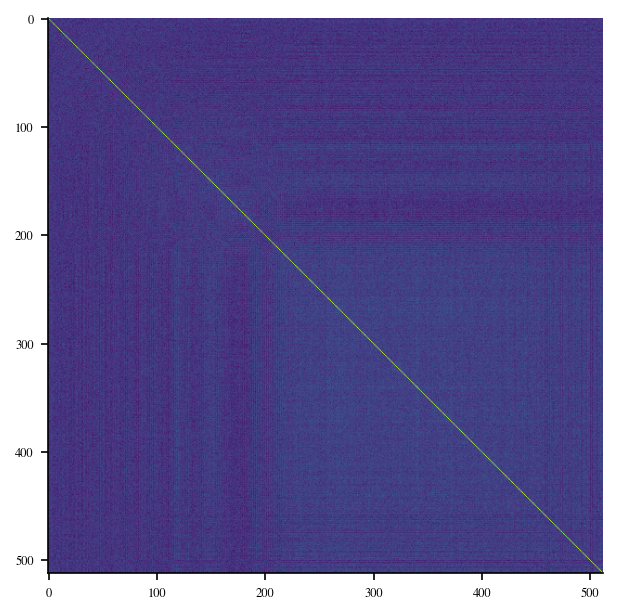

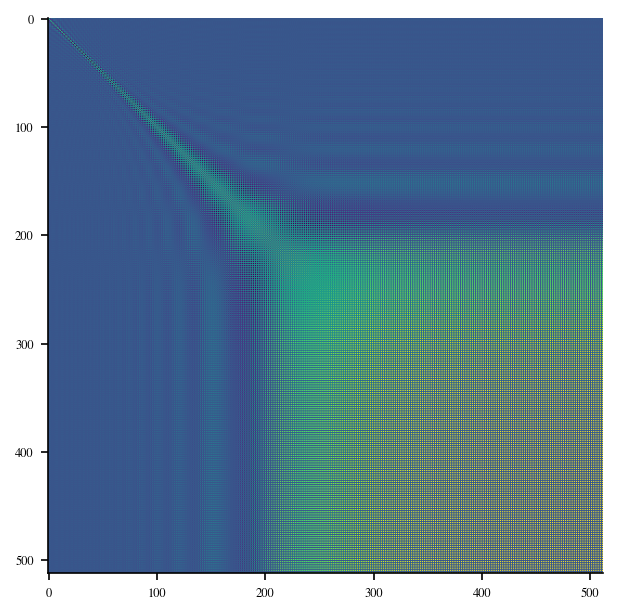

(4, 3)
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


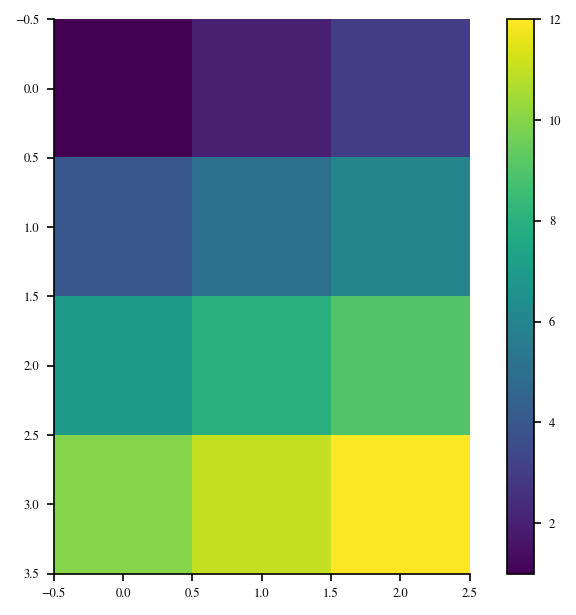

In [100]:
plt.imshow(W@W.T)
plt.show()

plt.imshow(p.T@p)
plt.show()

M = np.array([[1,2,3],[4,5,6],[7,8,9],[10,11,12]])
print(M.shape)
print(M)
plt.imshow(M)
plt.colorbar()
plt.show()

In [338]:
l = 'training_wave_positions_L128_batch_size64_beta1_d512_dataset_size10000_fr_attFalse_fr_embFalse_lr0.05_rankNone_sigma0.1_skip_residualFalse_type_encwave.png'
len(l)

155

# Others

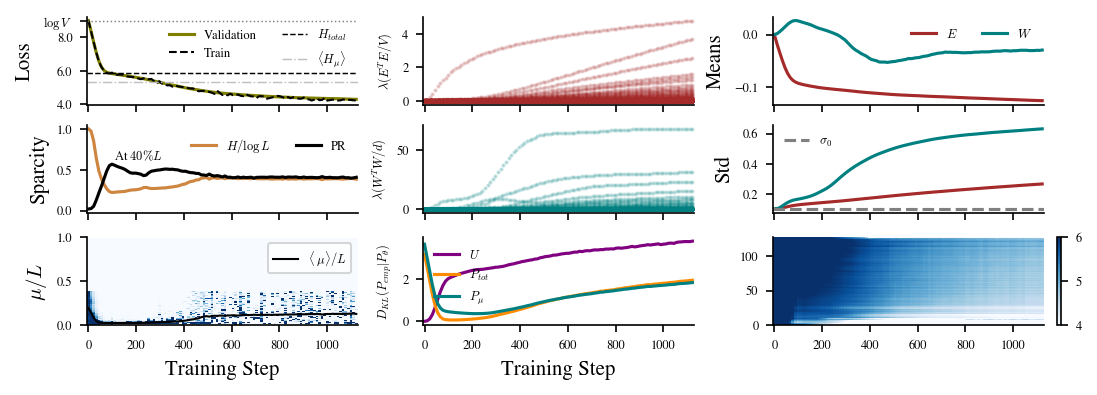

In [336]:
# Setup and variables
step_scalar = summary_scalar['evaluation_steps']
vocab_size = int(summary_scalar['vocab_size'])
sequence_fractions = summary_scalar['sequence_fractions']
i_seq_frac = 1
set_font_sizes(conf='tight')
color_E = 'brown'
color_W = 'teal'

# Create figure
fig , axes = create_fig(nrows=3,ncols=3,size='double',h=0.35)



# Loss
ax = axes[0,0]
ax.plot(step_scalar,summary_scalar['val_loss'], label='Validation', color='olive',ls='-')
ax.plot(step_scalar,summary_scalar['train_loss'], label='Train', color='k',ls='--',lw=1)
ax.axhline(np.log(vocab_size), color='gray', ls=':', lw=0.7)
ax.axhline(total_entropy, color='k', ls='--', lw=.7, label=r'$H_{total}$')
ax.axhline(entropies.mean(), color='silver', ls='-.', lw=.7, label=r'$\langle H_\mu \rangle$')

ax.set_ylabel('Loss')
ax.legend(frameon=False,ncols=2)
# yticks = ax.get_yticks()
yticks = [4,6,8]
ylabels = [f'{y:.1f}' for y in yticks]
ax.set_yticks([*yticks,np.log(vocab_size)], [*ylabels, r'$\log V$'])

# Sparcity Measures
ax = axes[1,0]
ax.plot(step_scalar, summary_scalar['entropy'][:,i_seq_frac], label=r'$H/\log L$', color='peru',ls='-')
ax.plot(step_scalar, summary_scalar['part_ratio'][:,i_seq_frac], label='PR', color='k',ls='-')
ax.set_ylabel('Sparcity')
ax.legend(frameon=False,ncols=2,loc='upper right')
ax.text(x=0.1, y=0.6, 
        s=fr'At ${ 100* sequence_fractions[i_seq_frac]:.0f} \% L$',
        transform=ax.transAxes,
        fontsize=FONTSIZES['xs'])


# Attention Pattern
ax = axes[2,0]

attention_patterns = summary_scalar['att_in_fractions']  # (num_step_scalars, len(seq_fract), L)
mesh = ax.pcolormesh(step_scalar, np.arange(L)/L, attention_patterns[:, i_seq_frac].T,cmap='Blues',vmax=0.02)
ax.plot(step_scalar,sequence_fractions[i_seq_frac]*summary_scalar['pos_attended'][:,i_seq_frac], 
        label=r'$\langle \;\mu \rangle / L$', color='k',ls='-',lw=1)

# plt.colorbar(mesh, ax=ax)
ax.legend(frameon=True,ncols=2)
ax.set_ylim(0,1)
ax.set_ylabel(r'$\mu / L$')
ax.set_xlabel('Training Step')


# Embedding Eigenvalues
ax = axes[0,1]
for i , t in enumerate(step_scalar):
    ax.scatter([t]*d,summary_scalar['embedd_eigvals'][i],s=1,alpha=0.2,color=color_E)
ax.set_ylabel(r'$\lambda(E^T E / V)$',size=FONTSIZES['xs'])

# Weight Eigenvalues
ax = axes[1,1]
for i , t in enumerate(step_scalar):
    ax.scatter([t]*d,summary_scalar['W_eigvals'][i],s=1,alpha=0.2,color=color_W)
ax.set_ylabel(r'$\lambda(W^T W / d)$',size=FONTSIZES['xs'])

# Gradients
# ax = axes[2,1]
# ax.plot(step_scalar,summary_scalar['grad_embedding'], label=r'$\nabla E$', color=color_E,ls='-')
# ax.plot(step_scalar,summary_scalar['grad_W'], label=r'$\nabla W$', color=color_W,ls='-')
# ax.set_ylabel('Gradients')
# # ax.legend(frameon=False,ncols=2)
# ax.set_xlabel('Training Step')

# KL divergences
ax = axes[2,1]
ax.plot(step_scalar,summary_scalar['KL_uniform'], label=r'$U$', color='purple',ls='-')
ax.plot(step_scalar,summary_scalar['KL_tot'], label=r'$P_{tot}$', color='darkorange',ls='-')
ax.plot(step_scalar,summary_scalar['KL_mu'], label=r'$P_{\mu}$', color='teal',ls='-')
ax.set_ylabel(r'$D_{KL}(P_{emp}|P_{\theta})$',size=FONTSIZES['xs'])
ax.legend(frameon=False,ncols=1)
ax.set_xlabel('Training Step')

# Means
ax = axes[0,2]
ax.plot(step_scalar,summary_scalar['embedd_mean'], label=r'$E$', color=color_E,ls='-')
ax.plot(step_scalar,summary_scalar['W_mean'], label=r'$W$', color=color_W,ls='-')
ax.set_ylabel('Means')
ax.legend(frameon=False,ncols=2)

# Stddevs
ax = axes[1,2]
ax.plot(step_scalar,summary_scalar['embedd_std'], color=color_E,ls='-')
ax.plot(step_scalar,summary_scalar['W_std'], color=color_W,ls='-')
ax.axhline(sigma,color='gray',ls='--',label=r'$\sigma_0$')
ax.set_ylabel(r'Std')
ax.legend(frameon=False,ncols=1)


# Prediction Entropy
ax = axes[2,2]
cmesh = ax.pcolormesh(step_scalar, np.arange(config['L']), summary_scalar['pred_entropy'].T, cmap='Blues',vmax=6,vmin=4.)
plt.colorbar(cmesh,ax=ax)
# ax.set_xlim(0,100)
# ax.set_ylim(0,0.5)
# ax.set_xscale('log')

# names = ['d','L','lr','fr_emb','fr_att','skip_residual','type_enc','beta']
# params = make_params_dict(names)
# save_fig(fig,'measures',params=params)

In [106]:
# Define configuration

config = {
    'dataset_size': 10000,
    'train_fraction': 0.9,
    'batch_size': 10,
    'L': 128,
    'datasource': 'roneneldan/TinyStories',
}

# Prepare data loaders and tokenizer
print('Preparing data loaders...')
train_dataloader, val_dataloader , tokenizer = get_dataloader(config)
vocab_size = tokenizer.get_vocab_size()
print(f'Vocabulary size = {vocab_size}. Maximum entropy per token = {np.log(vocab_size):.4f} nats.')
pad_id = tokenizer.token_to_id("[PAD]")

Preparing data loaders...
Min sequence length = 53
Max sequence length = 1040
Vocabulary size = 8043. Maximum entropy per token = 8.9926 nats.


In [138]:

def get_special_batch(dataloader,L,k=3):

    num_max_len = 0
    while num_max_len < k:
        special_batch = next(iter(dataloader))
        seq_lens = special_batch['tokens_len'].numpy()
        num_max_len = np.sum(seq_lens == L-1)

    # Keep only top k elements in special_batch with the highest token lengths

    lengths = special_batch['tokens_len'].numpy()  # Convert to NumPy array if needed
    top_k_indices = np.argsort(-lengths)[:k]      # Indices of top k lengths

    for key in special_batch.keys():
        value = special_batch[key]
        # If value is a PyTorch tensor, use tensor indexing
        if isinstance(value, torch.Tensor):
            special_batch[key] = value[top_k_indices]
        # If value is a NumPy array, use NumPy indexing
        elif isinstance(value, np.ndarray):
            special_batch[key] = value[top_k_indices]
        # If value is a list, use list comprehension
        elif isinstance(value, list):
            special_batch[key] = [value[i] for i in top_k_indices]
        else:
            # If value is another type, leave it unchanged or handle as needed
            raise TypeError(f"Unsupported data type for key '{key}': {type(value)}")
        
    return special_batch


In [142]:
special_batch = get_special_batch(train_dataloader,config['L'],k=3)
special_batch['tokens_len']

tensor([127, 127, 127])

In [125]:
for key in special_batch.keys():
    value = special_batch[key]
    if isinstance(value,torch.Tensor): 
        print('torch')
    elif isinstance(value,np.ndarray):
        print('np')
    elif isinstance(value, list):
        print('list')

torch
torch
torch
list
torch
